Sentiment Analysis on Twitter Data   

Internship - Oasis Infobyte (OIBSIP)    
Project 4, Proposal Level 1  
Author - Aniket Mishra

Objective -  

The primary goal is to develop a sentiment analysis model that can accurately classify the sentiment of text data, providing valuable insights into public opinion, customer feedback and social media trends.

Understanding The Dataset -  

The dataset contains Twitter posts and their respective sentiment labels. Each tweet is classified as positive, neutral or negative.  
Before building the model and performing analysis, the dataset structure would be examined to understand the number of columns, data types and missing values.

In [1]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

In [2]:
# Load Dataset

df = pd.read_csv("D:/Downloads/Twitter_Data.csv.zip")
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


Observation -  

In the dataset `clean_text` column contains `the text of each tweet`, whereas, `category` column contains the `sentiment` of that tweet.  
The sentiment labels are: Positive, Neutral and Negative which are shown by +1, 0 and -1 respectively.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  str    
 1   category    162973 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.5 MB


Observation -  

The dataset contains only two columns, `clean_text` which is stored as `text` and `category` which is stored as `numerical values`.  
There are some missing values which be can indicated by non null countas it's lower than total entries.

In [4]:
# Checking Missing Values

df.isnull().sum()

clean_text    4
category      7
dtype: int64

In [5]:
# Dropping Missing Values

df.dropna(inplace = True)

Observation -  

Since the dataset contains a very small number of missing values, therefore removing them does not affect the overall analysis.

In [6]:
# Checking Duplicate Values

df.duplicated().sum()

np.int64(0)

Observation - 

Since there are no duplicate values present, therefore no need to remove them and we can move forward.

In [7]:
# Data Cleaning  

df["clean_text"] = df["clean_text"].str.lower()

df["clean_text"] = df["clean_text"].str.replace(r"http\S+","", regex = True)

df["clean_text"] = df["clean_text"].str.replace(r"[^a-zA-Z\s]","", regex = True)

Observation -  

The text data was cleaned before training the model.  
The tweets were cleaned by converting all text to lowercase, removing URLs, punctuations and special characters. It will make the data more consistent.

In [8]:
df["category"].value_counts()

category
 1.0    72249
 0.0    55211
-1.0    35509
Name: count, dtype: int64

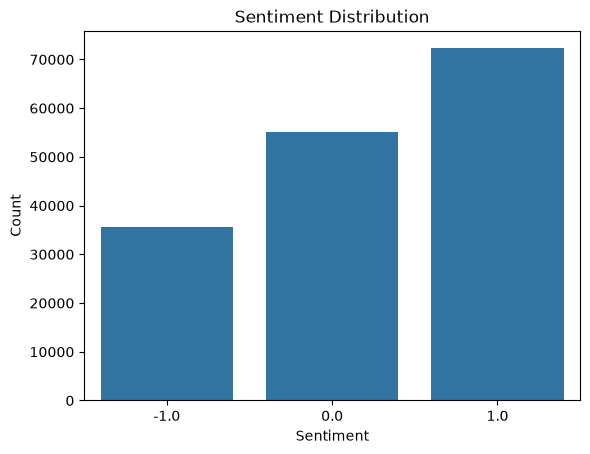

In [9]:
sns.countplot(x = "category", data = df)
plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Observation -  

The graph contains three sentiment classes. Positive tweets are the most common, while negative tweets are the fewest.  
Although the classes are not perfectly balanced, all three sentiments are well represented, allowing the model to learn from each category.

In [10]:
X = df["clean_text"]
Y = df["category"]

Observation -  

The columns are selected and they will be used by the machine learning model.

In [11]:
# Splitting the Dataset

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

Observation -  

The dataset was divided into 80% for `training` and 20% for `testing`.    
The training data will be used to teach the model, while the testing data will be used to evaluate how well the model performs on unknown tweets.  
`stratify = Y` is used so that positive, neutral and negative tweets remain in the same proportion.

In [12]:
# Creating TF-IDF Vectorizer

vectorizer = TfidfVectorizer(ngram_range = (1,2), max_features = 30000)

In [13]:
# Applying TF-IDF

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

Observation -  

Machine learning models cannot understand text directly, therefore `TF-IDF` is used to convert tweets into numerical values based on the importance of each word.  
This allows the model to learn patterns from text.

In [14]:
# Training Model  

model = LogisticRegression(max_iter = 1000)
model.fit(X_train, Y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Observation -  

A `Logistic Regression model` was trained using the `TF-IDF features`.  
It learned the relationship between words and their respective sentiments, enabling it to predict whether a new tweet is positive, neutral or negative.

In [15]:
Y_pred = model.predict(X_test)

In [16]:
# Accuracy Analysis

accuracy_score(Y_test, Y_pred)

0.9183898877093943

Observation -   

The model achieved an accuracy of 91%.   
This high accuracy shows that the model learned the sentiment patterns effectively.

In [17]:
# Classification Report 

print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

        -1.0       0.92      0.80      0.86      7102
         0.0       0.90      0.97      0.94     11042
         1.0       0.93      0.93      0.93     14450

    accuracy                           0.92     32594
   macro avg       0.92      0.90      0.91     32594
weighted avg       0.92      0.92      0.92     32594



Observation -    

The classification report provides `Precision`, `Recall` and `F1-score` for each sentiment class.  
High values indicate that the model correctly identifies tweets with consistency.  

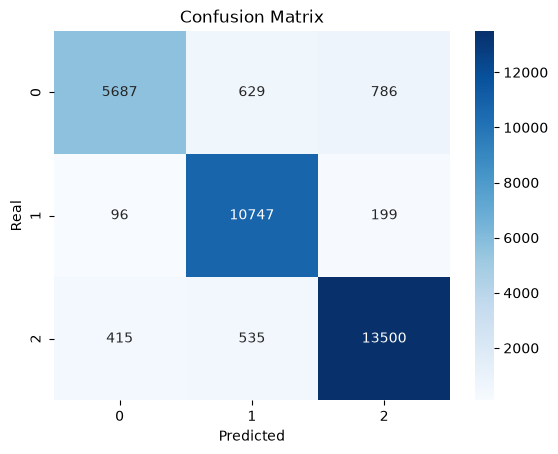

In [35]:
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

Observation -   

The confusion matrix compares the real sentiments with the predicted ones. `X axis` represents the `sentiment predicted` by the model, where as `Y axis`  represents the `real sentiment` of the tweet.   
Most values appear along the diagonal, showcasing that the majority of tweets were correct. Only a small number of tweets were misclassified.

In [33]:
example = ["He is doing a great job"]
example_vector = vectorizer.transform(example)
prediction = model.predict(example_vector)
print(prediction)

[1.]


In [34]:
example = ["This football match was the worst match i haver ever seen"]
example_vector = vectorizer.transform(example)
prediction = model.predict(example_vector)
print(prediction)

[-1.]


Key Insights -  

1. The dataset contains 162,980 tweets classified into positive, neutral and negative sentiments.  
2. Positive tweets are the most common, while negative tweets are the least frequent.  
3. Data Cleaning that is, lowercasing, removing URLs and special characters improved the quality and consistency of the data.  
4. TF-IDF successfully converted text into numerical features that could be understood by the machine learning model.  
5. Logistic Regression achieved an accuracy of 91%, showing strong performance in classifying tweet sentiments.  
6. The confusion matrix showed that most tweets were correctly classified.
   

Recommendations -

1. Balance the sentiment classes to reduce any bias towards the minority class, that is negative and neutral sentiment.    
2. Collect more recent Twitter data so that the model understand newer trends and patterns.    

Conclusion -  

1. Sentiment analysis model was successfully developed using the Twitter dataset.  
2. It achieved high prediction accuracy, after cleaning the dataset, converting it into TF-IDF feature and training a Logistic Regression model.  
3. The results show that the model can effectively classify tweets into positive, neutral and negative sentiments.  
4. Now it can be used for analysing public opinion on social media.